In [3]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from functions import read_json
import nb_core_news_sm # Might need nltk to be downloaded
import nltk

# Only need to run once, but needs nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\henni\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [4]:
# Import data from the json-file

filename = 'sprakradet_clean.json'

text = read_json(filename=filename, sections=('answer', 'question'))

In [5]:
# Stopwords and lemmatisation

norwegian_stopwords = set(stopwords.words('norwegian'))

nlp = nb_core_news_sm.load()

def chunk_text(text, max_chars=200_000):
    for i in range(0, len(text), max_chars):
        yield text[i:i + max_chars]

lemmas = []

for chunk in chunk_text(text, max_chars=200_000):
    doc = nlp(chunk)
    lemmas.extend(
        token.lemma_.lower()
        for token in doc if not token.is_punct and not token.is_space
    )

filtered_lemmas = [w for w in lemmas if w not in norwegian_stopwords]
filtered_text = ' '.join(filtered_lemmas)

In [6]:
# Make word cloud

wc = WordCloud(
    width=1200,
    height= 800,
    background_color='white',
    max_words=100,
    colormap='viridis'
)

wordcloud = wc.generate(filtered_text)

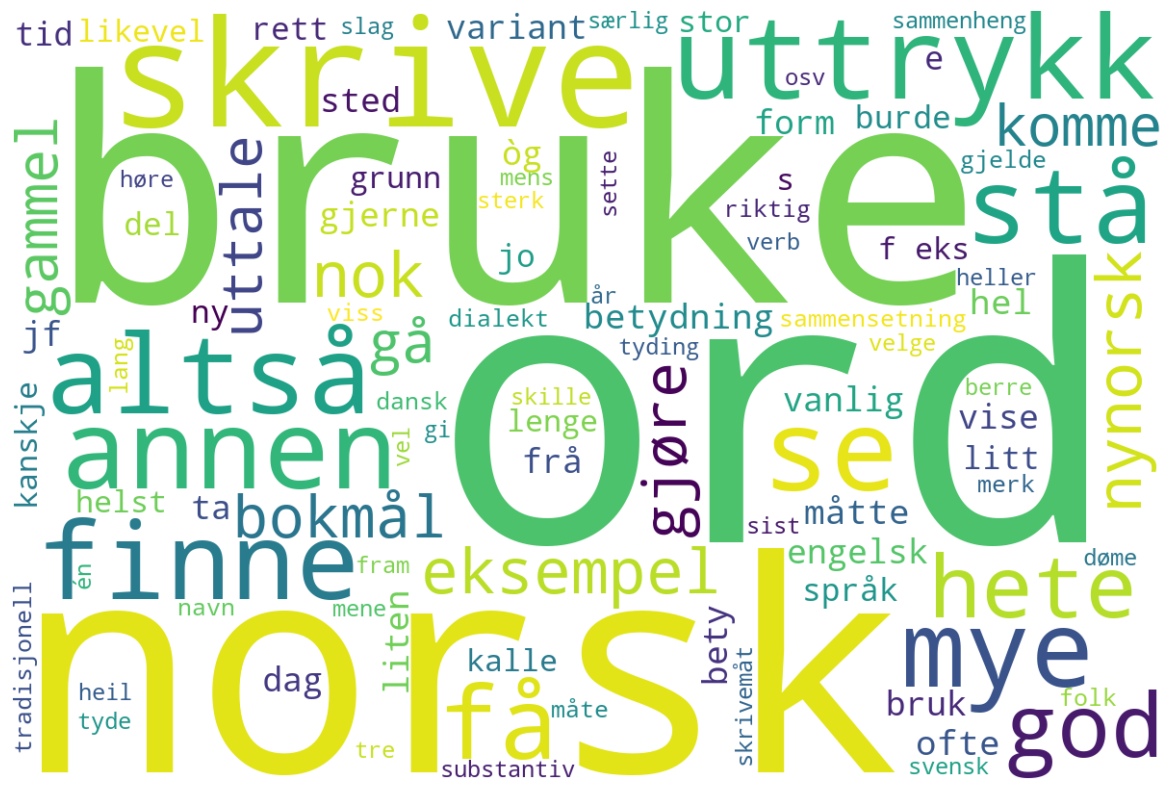

In [7]:
# Figure

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()